# 系统工具

In [1]:
import quante.basicfun as bf

## 代码调试工具

### 显示代码运行运行的时间

In [31]:
import numpy as np

def singlestep(a, i, j):
    a = np.sin(a)
    return a + i + j

def myfun(dim):
    mat = np.random.randn(dim,dim)
    for i in range(dim):
        for j in range(dim):
            mat[i,j] = singlestep(mat[i,j], i, j)
    return mat

with bf.timing([myfun,singlestep]):
    myfun(100)

Timer unit: 0.001 s

Total time: 0.0208417 s
File: C:\Users\hzhu\AppData\Local\Temp\ipykernel_54008\3929419653.py
Function: singlestep at line 3

Line #      Hits         Time  Per Hit   % Time  Line Contents
     3                                           def singlestep(a, i, j):
     4     10000         15.7      0.0     75.2      a = np.sin(a)
     5     10000          5.2      0.0     24.8      return a + i + j

Total time: 0.0486645 s
File: C:\Users\hzhu\AppData\Local\Temp\ipykernel_54008\3929419653.py
Function: myfun at line 7

Line #      Hits         Time  Per Hit   % Time  Line Contents
     7                                           def myfun(dim):
     8         1          0.4      0.4      0.8      mat = np.random.randn(dim,dim)
     9       101          0.0      0.0      0.1      for i in range(dim):
    10     10100          3.1      0.0      6.3          for j in range(dim):
    11     10000         45.1      0.0     92.7              mat[i,j] = singlestep(mat[i,j], i,

显示了每一行运行需要的时间

如何是 py 文件中，可以使用 profile 装饰器

```python
@bf.profile()
def singlestep(a, i, j):
    a = np.sin(a)
    return a + i + j

@bf.profile()
def myfun(dim):
    mat = np.random.randn(dim,dim)
    for i in range(dim):
        for j in range(dim):
            mat[i,j] = singlestep(mat[i,j], i, j)
    return mat

myfun(100)
```

### 查看变量占用的内存

python 自带的内存大小函数只会显示指针占用内存

In [32]:
a = [np.random.rand(1000,1000)]
import sys
sys.getsizeof(a)

64

使用 test_memory 可以正确显示内存占用大小

In [34]:
bf.print_memory_usage(a)

7.63 MB


## 数据保存

In [ ]:
a = np.random.randn(10,10)
bf._save_hdf5("data.h5", a)  # 这样会建立一个 data.h5 文件，里面包含一个名为 "a" 的数据集

In [8]:
a = bf._load_hdf5("data.h5", "a")  # 这样可以得到储存的数据

也支持多个数据的的保存和导入

In [9]:
a = [1,2,3]
b = np.random.randn(10,10)

# c, d 不能被 hdf5 直接保存，将会被序列化，失去可视化的效果
c = [a, b]
class D:
    def __init__(self, x):
        self.x = x
d = D(10)

bf._save_hdf5("data.h5", a, b, c, d)  

In [10]:
a, b, c, d = bf._load_hdf5("data.h5", "a", "b", "c", "d")

如果涉及到 group，可以：

In [11]:
a = np.random.randn(10,10)
bf.save_hdf5("data.h5", "/", {"a": a})

('data.h5', '/')

In [12]:
a = bf.load_hdf5('data.h5', '/', 'a')

这种写法下，如果需要 load 更多元素，可以：

In [13]:
a = bf.load_hdf5('data.h5', '/', '/')

## 保存日志

通过在项目最开始运行：

In [14]:
bf.set_logging(savelog=True, logtime=True)

可以将所有 `bf.println` 的输出保存到 log 文件中，同时记录时间。

报错信息同样会记录到 log 文件中

In [15]:
bf.println("hello world")

In [16]:
bf.set_logging(savelog=False, logtime=True)
bf.println("hello world")

2024-11-09 22:27:22,168: hello world


In [17]:
bf.set_logging(savelog=False, logtime=False)
bf.println("hello world")

hello world


`bf.set_logging(savelog=False, logtime=False)` 时，`println` 与普通 print 功能相似，并且可以输出变量名：

In [18]:
a = [1,2,3]
b = [4,5,6]
bf.println(a, b)

a: [1, 2, 3], b: [4, 5, 6]


目前，`println` 的参数必须在同一行，否则会报错

In [19]:
a = [1,2,3]
b = 1
bf.println(a,
           b)

SyntaxError
([1, 2, 3], 1)


## 画图预设

matplotlib 默认的画图风格为：

Text(0, 0.5, '$\\sin x$')

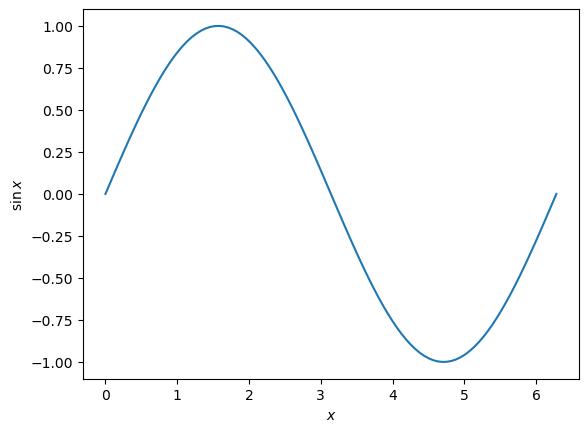

In [20]:
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel('$x$')
plt.ylabel('$\sin x$')

通过 `plt_style_use` 可以改变风格：

In [21]:
bf.plt_style_use()

Text(0, 0.5, '$\\sin x$')

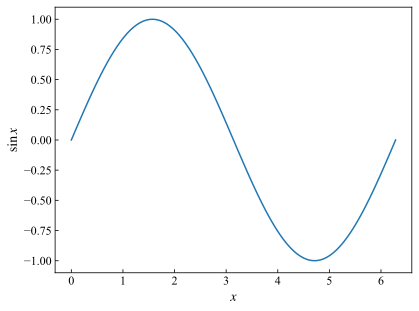

In [22]:
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

plt.plot(x, y)
plt.xlabel('$x$')
plt.ylabel('$\sin x$')